In [32]:
# =========================
# 0. Imports & Global Config
# =========================

import os
import glob
import warnings

import cv2
import numpy as np
import pandas as pd

import SimpleITK as sitk

from tqdm import tqdm
from radiomics import featureextractor

import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed, SHAP analysis will be skipped")

warnings.filterwarnings("ignore")
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

# ---------- Global Variables ----------
RANDOM_STATE = 42
K_BEST = 20
N_BOOTSTRAP = 1000

DATA_ROOT = r"D:\Research\data\Dataset_BUSI\Dataset_BUSI_with_GT"
TASK_DIR = r"D:\Research\medical-ml-learning\Task\Task 02"
FIG_DIR = os.path.join(TASK_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- Unified Colors ----------
MODEL_COLORS = {
    "Logistic Regression": "#185FA5",
    "Random Forest":       "#0F6E56",
    "SVM (RBF)":           "#534AB7",
}

print("Environment configured")
print(f"Data directory: {DATA_ROOT}")
print(f"Output directory: {FIG_DIR}")

Environment configured
Data directory: D:\Research\data\Dataset_BUSI\Dataset_BUSI_with_GT
Output directory: D:\Research\medical-ml-learning\Task\Task 02\figures


# Experiment Overview: BUSI Breast Ultrasound Radiomics Classification

## Task
Extract radiomics features from ROI regions to classify benign vs malignant breast lesions.

## Data
BUSI dataset — benign ~437 / malignant ~210 images, normal excluded (no lesion ROI).

## Feature Extraction Pipeline (PyRadiomics)

**102 features = shape2D(9) + firstorder(18) + glcm(24) + glrlm(16) + glszm(16) + gldm(14) + ngtdm(5)**

| Category | Count | Examples |
|----------|-------|----------|
| shape2D | 9 | Elongation, Sphericity, Perimeter |
| firstorder | 18 | Mean, Variance, Skewness, Kurtosis, Entropy |
| glcm | 24 | Contrast, Correlation, JointEnergy, MCC |
| glrlm | 16 | ShortRunEmphasis, LongRunEmphasis, RunEntropy |
| glszm | 16 | SmallAreaEmphasis, ZoneEntropy, ZoneVariance |
| gldm | 14 | SmallDependenceEmphasis, DependenceEntropy |
| ngtdm | 5 | Busyness, Coarseness, Contrast, Complexity |

## Models
- Logistic Regression (linear, class_weight='balanced')
- Random Forest (nonlinear, class_weight='balanced')
- SVM-RBF (nonlinear, class_weight='balanced')

## Evaluation
AUC / Accuracy / Sensitivity / Specificity + ROC / PR / Confusion matrix + 5-fold CV + Bootstrap CI

In [33]:
# =========================
# 1. Load BUSI dataset
# =========================

def load_busi_dataset(data_root):

    records = []

    for label_name, label in [
        ("benign", 0),
        ("malignant", 1)
    ]:

        folder = os.path.join(
            data_root,
            label_name
        )

        all_files = sorted(
            glob.glob(
                os.path.join(folder, "*.png")
            )
        )

        # remove mask images
        image_files = [
            f for f in all_files
            if "_mask" not in os.path.basename(f)
        ]

        for img_path in image_files:

            base = img_path.rsplit(".", 1)[0]

            mask_paths = sorted(
                glob.glob(
                    base + "_mask*.png"
                )
            )

            if len(mask_paths) == 0:
                continue

            records.append({

                "sample_id":
                    os.path.splitext(
                        os.path.basename(img_path)
                    )[0],

                "image_path":
                    img_path,

                "mask_paths":
                    mask_paths,

                "label":
                    label,

                "label_name":
                    label_name

            })

    df = pd.DataFrame(records)

    print("=" * 60)
    print("BUSI Dataset")
    print("=" * 60)

    print(df["label_name"].value_counts())

    print()

    print(
        "Total Samples:",
        len(df)
    )

    print(
        "Multiple ROI Samples:",
        df["mask_paths"]
        .apply(len)
        .gt(1)
        .sum()
    )

    return df


df_data = load_busi_dataset(DATA_ROOT)

BUSI Dataset
label_name
benign       437
malignant    210
Name: count, dtype: int64

Total Samples: 647
Multiple ROI Samples: 17


## Data Exploration & Visualization

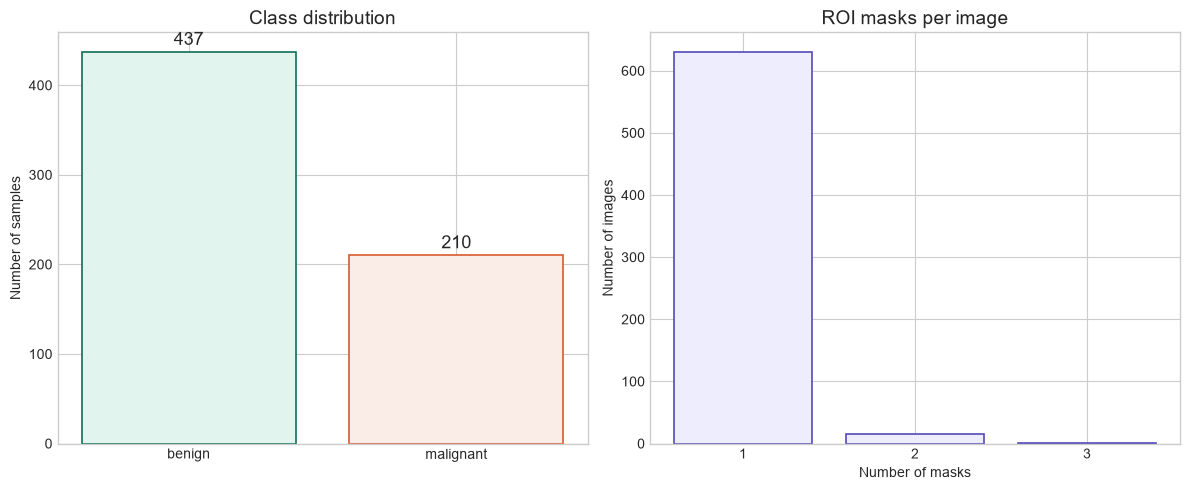

In [34]:
# =========================
# 2. Class Distribution & Mask Stats
# =========================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_data["label_name"].value_counts().reindex(["benign", "malignant"])
colors_cls = ["#E1F5EE", "#FAECE7"]
edge_cls = ["#0F6E56", "#D85A30"]

bars = axes[0].bar(counts.index, counts.values,
                   color=colors_cls, edgecolor=edge_cls, linewidth=1.2)
axes[0].set_title("Class distribution", fontsize=14, fontweight=500)
axes[0].set_ylabel("Number of samples")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(val), ha="center", fontsize=13, fontweight=500)

mask_counts = df_data["mask_paths"].apply(len).value_counts().sort_index()
axes[1].bar(mask_counts.index.astype(str), mask_counts.values,
            color="#EEEDFE", edgecolor="#534AB7", linewidth=1.2)
axes[1].set_title("ROI masks per image", fontsize=14, fontweight=500)
axes[1].set_xlabel("Number of masks")
axes[1].set_ylabel("Number of images")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

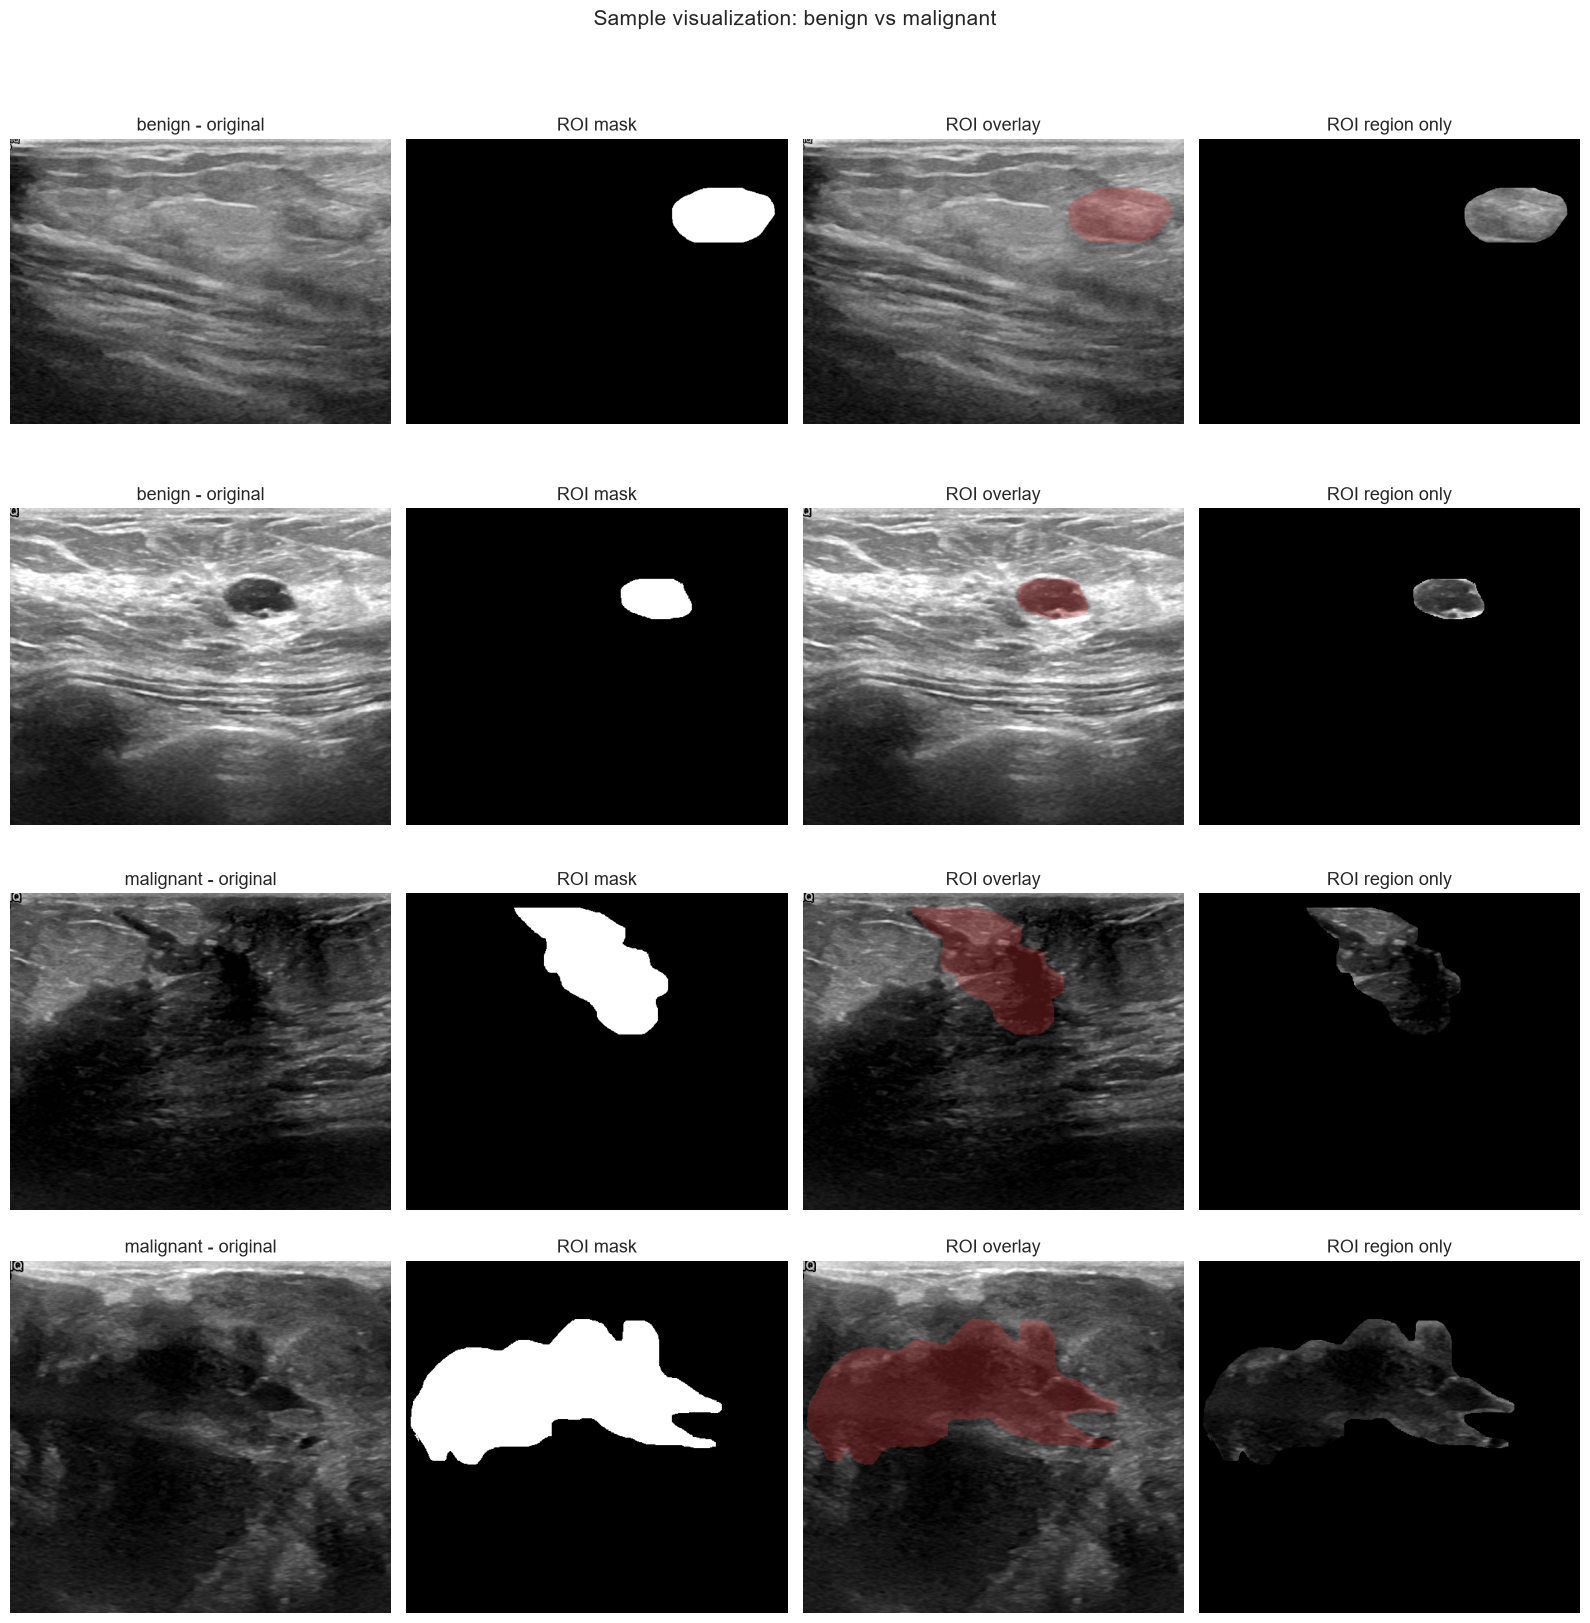

In [35]:
# =========================
# 3. Sample Visualization (Original + Mask Overlay)
# =========================

def merge_masks(mask_paths):

    merged = None

    for path in mask_paths:

        mask = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            raise ValueError(
                f"Cannot read mask: {path}"
            )

        # binary mask
        mask = (
            mask > 0
        ).astype(np.uint8)

        if merged is None:

            merged = mask

        else:

            merged = np.maximum(
                merged,
                mask
            )

    return merged


samples = df_data.groupby("label_name").sample(2, random_state=RANDOM_STATE)

n_samples = len(samples)
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
axes = np.atleast_2d(axes)

for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row["image_path"])
    if img is None:
        raise ValueError(f"Cannot read image: {row['image_path']}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = merge_masks(row["mask_paths"])

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f'{row["label_name"]} - original', fontsize=13)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("ROI mask", fontsize=13)
    axes[i, 1].axis("off")

    overlay = img_rgb.copy()
    overlay[mask > 0] = [220, 60, 60]
    blended = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)
    axes[i, 2].imshow(blended)
    axes[i, 2].set_title("ROI overlay", fontsize=13)
    axes[i, 2].axis("off")

    roi_img = img_rgb.copy()
    roi_img[mask == 0] = [0, 0, 0]
    axes[i, 3].imshow(roi_img)
    axes[i, 3].set_title("ROI region only", fontsize=13)
    axes[i, 3].axis("off")

plt.suptitle("Sample visualization: benign vs malignant",
             fontsize=15, fontweight=500, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_sample_vis.png"), dpi=150, bbox_inches="tight")
plt.show()

## PyRadiomics Feature Extraction

Using **PyRadiomics** library to extract 102 radiomics features from ROI regions.

Pipeline:
```
Original image I(x,y) -> ROI extraction (mask M) -> float32 conversion -> SimpleITK format -> PyRadiomics extractor -> 102 features
```

**Feature categories:**
- shape2D (9): Elongation, Sphericity, Perimeter, MajorAxisLength, ...
- firstorder (18): Mean, Variance, Skewness, Kurtosis, Entropy, ...
- glcm (24): Contrast, Correlation, JointEnergy, MCC, ...
- glrlm (16): ShortRunEmphasis, LongRunEmphasis, RunEntropy, ...
- glszm (16): SmallAreaEmphasis, ZoneEntropy, ZoneVariance, ...
- gldm (14): SmallDependenceEmphasis, DependenceEntropy, ...
- ngtdm (5): Busyness, Coarseness, Contrast, Complexity, Strength

In [36]:
# =========================
# 4. PyRadiomics settings
# =========================

settings = {

    "force2D": True,

    "force2Ddimension": 0,

    "label": 1,

    "binWidth": 25,

    "normalize": False,

    "preCrop": True

}


extractor = featureextractor.RadiomicsFeatureExtractor(
    **settings
)


extractor.disableAllFeatures()

# First order
extractor.enableFeatureClassByName(
    "firstorder"
)

# 2D shape
extractor.enableFeatureClassByName(
    "shape2D"
)

# Texture
for feature_name in [
    "glcm",
    "glrlm",
    "glszm",
    "gldm",
    "ngtdm"
]:

    extractor.enableFeatureClassByName(
        feature_name
    )


print("\nEnabled Features:")
print(extractor.enabledFeatures)


Enabled Features:
{'firstorder': [], 'shape2D': [], 'glcm': [], 'glrlm': [], 'glszm': [], 'gldm': [], 'ngtdm': []}


In [37]:
# =========================
# 5. Extract function
# =========================

def extract_radiomics(
        image_path,
        mask_paths
):

    # read image
    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:

        raise ValueError(
            f"Cannot read image: {image_path}"
        )

    # merge ROI
    mask = merge_masks(
        mask_paths
    )

    # =====================
    # Critical fix
    # =====================

    # image:
    # uint8 -> float32
    image = image.astype(
        np.float32
    )

    # mask:
    # binary label
    mask = (
        mask > 0
    ).astype(
        np.uint32
    )

    # numpy -> SimpleITK
    image_sitk = sitk.GetImageFromArray(
        image
    )

    mask_sitk = sitk.GetImageFromArray(
        mask
    )

    # keep geometry
    mask_sitk.CopyInformation(
        image_sitk
    )

    # radiomics
    feature = extractor.execute(
        image_sitk,
        mask_sitk
    )

    # remove diagnostics
    feature = {

        k: v

        for k, v in feature.items()

        if not k.startswith(
            "diagnostics"
        )

    }

    return feature

In [38]:
# =========================
# 6. Batch extraction
# =========================

feature_list = []
failed_cases = []


for row in tqdm(
    df_data.itertuples(index=False),
    total=len(df_data)
):

    try:

        feature = extract_radiomics(

            row.image_path,

            row.mask_paths

        )

        feature["sample_id"] = row.sample_id
        feature["label"] = row.label
        feature["label_name"] = row.label_name

        feature_list.append(feature)

    except Exception as e:

        failed_cases.append({

            "sample_id":
                row.sample_id,

            "image":
                row.image_path,

            "error":
                str(e)

        })

        print(
            "Skip:",
            row.sample_id
        )

100%|██████████| 647/647 [05:38<00:00,  1.91it/s]


In [39]:
# =========================
# 7. Result & Save
# =========================

feature_df = pd.DataFrame(
    feature_list
)

failed_df = pd.DataFrame(
    failed_cases
)

print("\n" + "=" * 60)
print("Radiomics Extraction Finished")
print("=" * 60)

print(
    "Successful Samples:",
    len(feature_df)
)

print(
    "Failed Samples:",
    len(failed_df)
)

print(
    "Feature Shape:",
    feature_df.shape
)


# Save
feature_path = os.path.join(
    TASK_DIR,
    "radiomics_features.csv"
)

feature_df.to_csv(
    feature_path,
    index=False
)

print(
    "\nSaved:",
    feature_path
)


Radiomics Extraction Finished
Successful Samples: 647
Failed Samples: 0
Feature Shape: (647, 105)



Saved: D:\Research\medical-ml-learning\Task\Task 02\radiomics_features.csv


## Load Extracted Features (CSV)

If `radiomics_features.csv` already exists, skip extraction and load directly.

In [40]:
# =========================
# 8. Load CSV & Feature Overview
# =========================

csv_path = os.path.join(TASK_DIR, "radiomics_features.csv")

if os.path.exists(csv_path):
    df_features = pd.read_csv(csv_path)
    print(f"Loaded from CSV: {csv_path}")
    print(f"Shape: {df_features.shape}")
else:
    print("CSV not found, please run extraction cells above first.")

# Feature columns (exclude metadata)
feature_cols = [c for c in df_features.columns
                if c not in ("sample_id", "label", "label_name")]

print(f"Total features: {len(feature_cols)}")
print(f"Samples: {len(df_features)}")

# Categorize by prefix
feature_categories = {}
for prefix, name in [
    ("original_shape2D", "shape2D"),
    ("original_firstorder", "firstorder"),
    ("original_glcm", "glcm"),
    ("original_glrlm", "glrlm"),
    ("original_glszm", "glszm"),
    ("original_gldm", "gldm"),
    ("original_ngtdm", "ngtdm"),
]:
    cols_in_cat = [c for c in feature_cols if c.startswith(prefix)]
    feature_categories[name] = cols_in_cat
    print(f"  {name}: {len(cols_in_cat)} dims")

print(f"\nTotal: {sum(len(v) for v in feature_categories.values())} dims")

print(f"\nClass-wise feature means:")
display(df_features.groupby("label_name")[feature_cols].mean().T.head(10))

Loaded from CSV: D:\Research\medical-ml-learning\Task\Task 02\radiomics_features.csv
Shape: (647, 105)
Total features: 102
Samples: 647
  shape2D: 9 dims
  firstorder: 18 dims
  glcm: 24 dims
  glrlm: 16 dims
  glszm: 16 dims
  gldm: 14 dims
  ngtdm: 5 dims

Total: 102 dims

Class-wise feature means:


label_name,benign,malignant
original_shape2D_Elongation,0.548439,0.641863
original_shape2D_MajorAxisLength,204.781263,288.665149
original_shape2D_MaximumDiameter,203.969709,305.507935
original_shape2D_MeshSurface,21433.530892,43449.242857
original_shape2D_MinorAxisLength,103.286185,181.027654
original_shape2D_Perimeter,530.913147,932.064403
original_shape2D_PerimeterSurfaceRatio,0.047161,0.030015
original_shape2D_PixelSurface,21434.075515,43449.766667
original_shape2D_Sphericity,0.843600,0.744720
original_firstorder_10Percentile,33.064989,28.171429


## GLCM Feature Extraction Pipeline Visualization ★

Visualizing the 6-step pipeline for GLCM texture feature extraction:
```
Original image I(x,y) -> ROI extraction (mask M) -> Grayscale histogram -> Grayscale discretization (★key step) -> GLCM matrix P(i,j|d,theta) -> Texture features
```

Note: PyRadiomics uses its own GLCM implementation internally. This visualization uses scikit-image to illustrate the concept.

Grayscale range: min=0, max=214
binWidth=13.38, Ng=16
(PyRadiomics actual binWidth=25, here using Ng=16 for visualization)


findfont: Failed to find font weight 500, now using 400.


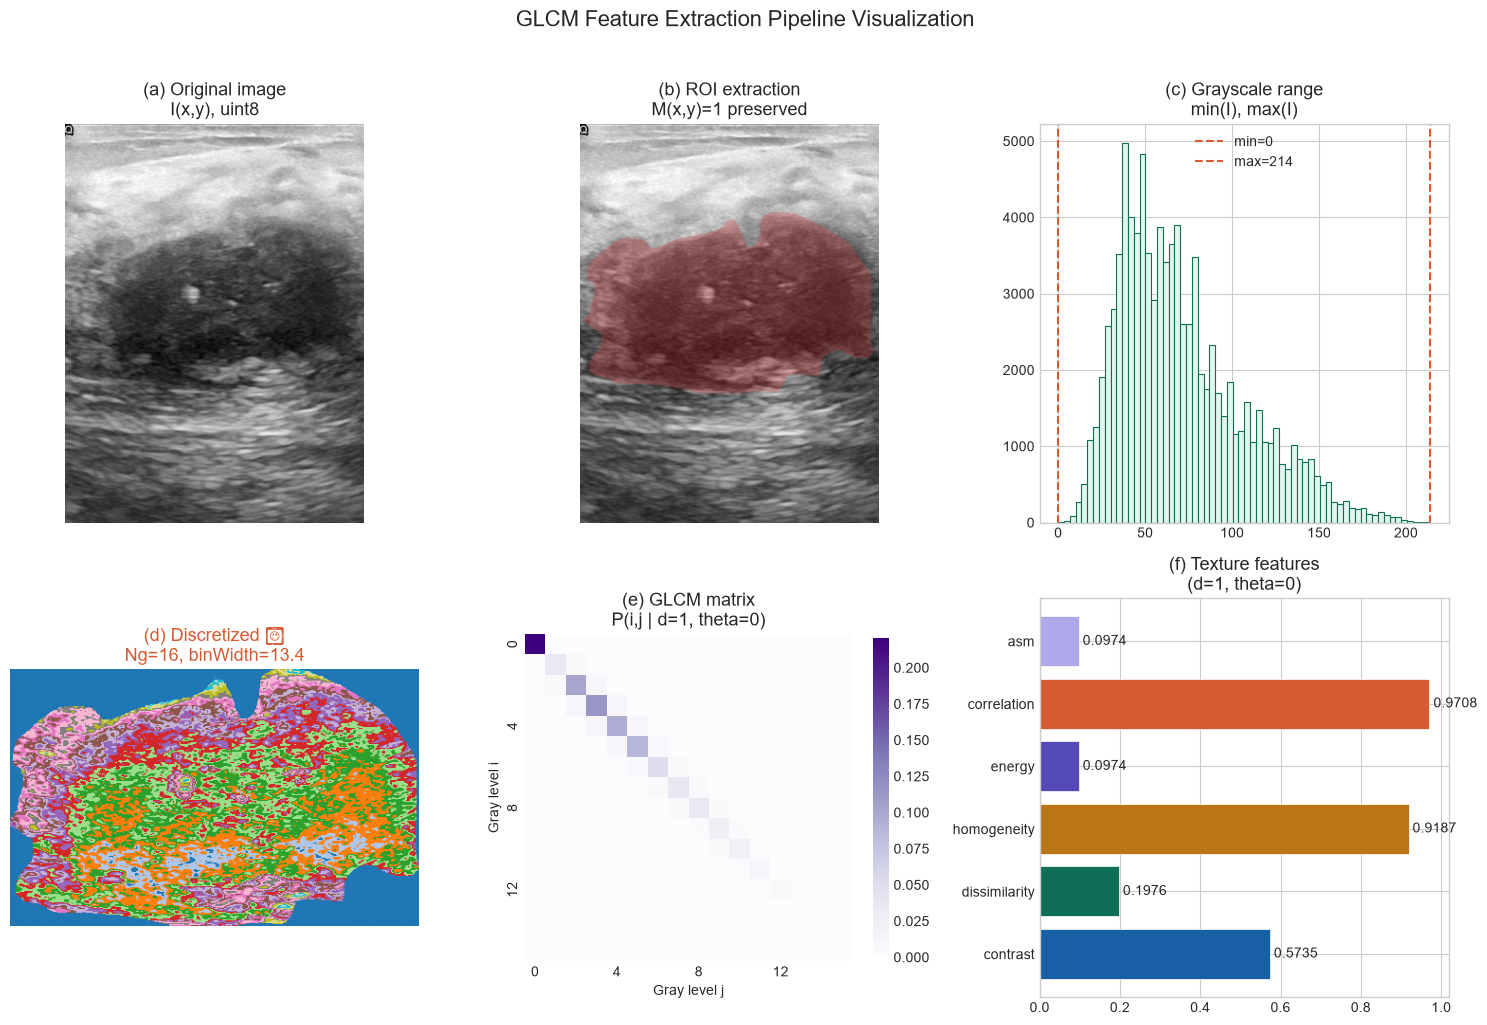


Texture feature values (d=1, theta=0):
  contrast        = 0.5735
  dissimilarity   = 0.1976
  homogeneity     = 0.9187
  energy          = 0.0974
  correlation     = 0.9708
  asm             = 0.0974


In [41]:
# =========================
# 9. GLCM Pipeline Visualization
# =========================

from skimage.feature import graycomatrix

# Compute GLCM properties manually
# (avoids greycoprops API changes across scikit-image versions)
def compute_glcm_props(glcm_matrix):
    """Compute 6 common GLCM texture properties from normalized matrix."""
    Ng = glcm_matrix.shape[0]
    i_idx = np.arange(Ng)
    j_idx = np.arange(Ng)
    diff = i_idx[:, None] - j_idx[None, :]
    contrast = np.sum(diff ** 2 * glcm_matrix)
    dissimilarity = np.sum(np.abs(diff) * glcm_matrix)
    homogeneity = np.sum(glcm_matrix / (1.0 + diff ** 2))
    energy = np.sum(glcm_matrix ** 2)
    asm = energy
    mu_i = np.sum(i_idx[:, None] * glcm_matrix)
    mu_j = np.sum(j_idx[None, :] * glcm_matrix)
    sigma_i = np.sqrt(np.sum((i_idx[:, None] - mu_i) ** 2 * glcm_matrix))
    sigma_j = np.sqrt(np.sum((j_idx[None, :] - mu_j) ** 2 * glcm_matrix))
    if sigma_i > 0 and sigma_j > 0:
        correlation = np.sum((i_idx[:, None] - mu_i) * (j_idx[None, :] - mu_j) * glcm_matrix) / (sigma_i * sigma_j)
    else:
        correlation = 0.0
    return {
        "contrast": contrast, "dissimilarity": dissimilarity,
        "homogeneity": homogeneity, "energy": energy,
        "correlation": correlation, "asm": asm,
    }


# Select a malignant sample for visualization
sample_row = df_data[df_data["label_name"] == "malignant"].iloc[0]
image = cv2.imread(sample_row["image_path"], cv2.IMREAD_GRAYSCALE)
mask = merge_masks(sample_row["mask_paths"])

# Step 1-3: ROI crop & grayscale range
ys, xs = np.where(mask > 0)
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()
cropped = image[y_min:y_max+1, x_min:x_max+1]
cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]
roi_pixels = image[mask > 0]
min_val, max_val = roi_pixels.min(), roi_pixels.max()
print(f"Grayscale range: min={min_val}, max={max_val}")

# Step 4: Discretization (PyRadiomics uses binWidth=25)
Ng = 16
bin_width = (max_val - min_val) / Ng
quantized = np.clip(((cropped.astype(np.float64) - min_val) / bin_width).astype(np.int32),
                    0, Ng - 1)
quantized[cropped_mask == 0] = 0
print(f"binWidth={bin_width:.2f}, Ng={Ng}")
print(f"(PyRadiomics actual binWidth=25, here using Ng=16 for visualization)")

# Step 5: GLCM matrix (d=1, theta=0)
glcm = graycomatrix(quantized, distances=[1], angles=[0],
                    levels=Ng, symmetric=True, normed=True)
glcm_matrix = glcm[:, :, 0, 0]

# Step 6: Texture features (computed from GLCM matrix directly)
props_demo = compute_glcm_props(glcm_matrix)

# ====== 6-step pipeline figure ======
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# (a) Original image
axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("(a) Original image\nI(x,y), uint8", fontsize=13, fontweight=500)
axes[0, 0].axis("off")

# (b) ROI extraction
overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
overlay[mask > 0] = [220, 60, 60]
blended = cv2.addWeighted(cv2.cvtColor(image, cv2.COLOR_GRAY2RGB), 0.7, overlay, 0.3, 0)
axes[0, 1].imshow(blended)
axes[0, 1].set_title("(b) ROI extraction\nM(x,y)=1 preserved", fontsize=13, fontweight=500)
axes[0, 1].axis("off")

# (c) Grayscale range
axes[0, 2].hist(roi_pixels, bins=64, color="#E1F5EE", edgecolor="#0F6E56", linewidth=0.8)
axes[0, 2].axvline(min_val, color="#D85A30", linestyle="--", label=f"min={min_val}")
axes[0, 2].axvline(max_val, color="#D85A30", linestyle="--", label=f"max={max_val}")
axes[0, 2].set_title("(c) Grayscale range\nmin(I), max(I)", fontsize=13, fontweight=500)
axes[0, 2].legend(fontsize=10)

# (d) Discretization ★
axes[1, 0].imshow(quantized * (cropped_mask > 0), cmap="tab20", vmin=0, vmax=Ng-1)
axes[1, 0].set_title(f"(d) Discretized ★\nNg={Ng}, binWidth={bin_width:.1f}",
                     fontsize=13, fontweight=500, color="#D85A30")
axes[1, 0].axis("off")

# (e) GLCM matrix
sns.heatmap(glcm_matrix, ax=axes[1, 1], cmap="Purples", square=True,
            xticklabels=4, yticklabels=4, cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("(e) GLCM matrix\nP(i,j | d=1, theta=0)", fontsize=13, fontweight=500)
axes[1, 1].set_xlabel("Gray level j")
axes[1, 1].set_ylabel("Gray level i")

# (f) Texture features
prop_names = list(props_demo.keys())
prop_vals = list(props_demo.values())
bar_colors = ["#185FA5", "#0F6E56", "#BA7517", "#534AB7", "#D85A30", "#AFA9EC"]
axes[1, 2].barh(prop_names, prop_vals, color=bar_colors, edgecolor="white", linewidth=0.5)
axes[1, 2].set_title("(f) Texture features\n(d=1, theta=0)", fontsize=13, fontweight=500)
for j, v in enumerate(prop_vals):
    axes[1, 2].text(v + 0.01, j, f"{v:.4f}", va="center", fontsize=10)

plt.suptitle("GLCM Feature Extraction Pipeline Visualization",
             fontsize=16, fontweight=500, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_glcm_pipeline.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nTexture feature values (d=1, theta=0):")
for k, v in props_demo.items():
    print(f"  {k:15s} = {v:.4f}")

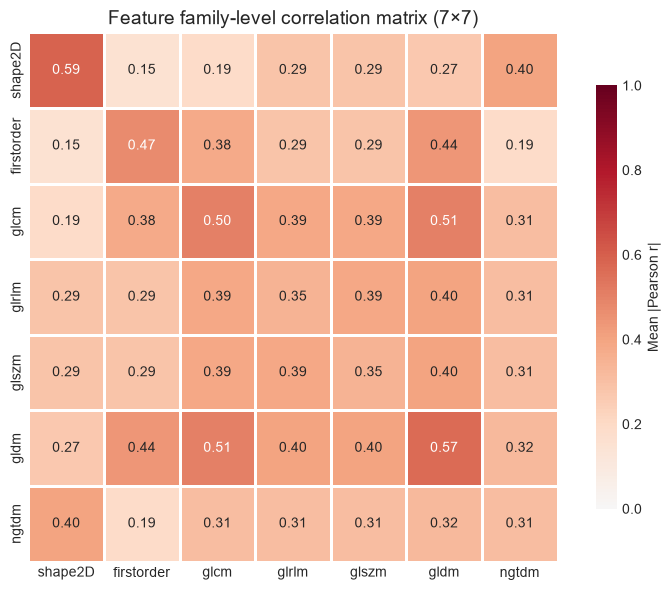


7×7 Family-level correlation interpretation:
  shape2D       intra-family redundancy = 0.59  (high)
  firstorder    intra-family redundancy = 0.47  (moderate)
  glcm          intra-family redundancy = 0.50  (high)
  glrlm         intra-family redundancy = 0.35  (moderate)
  glszm         intra-family redundancy = 0.35  (moderate)
  gldm          intra-family redundancy = 0.57  (high)
  ngtdm         intra-family redundancy = 0.31  (moderate)

|r| > 0.95 redundant pairs (133 total, showing top 15):
  firstorder_Energy                        vs firstorder_TotalEnergy                    r = 1.000
  glcm_JointAverage                        vs glcm_SumAverage                           r = 1.000
  glrlm_GrayLevelNonUniformity             vs glszm_GrayLevelNonUniformity              r = 1.000
  glrlm_GrayLevelNonUniformityNormalized   vs glszm_GrayLevelNonUniformityNormalized    r = 1.000
  glrlm_GrayLevelVariance                  vs glszm_GrayLevelVariance                   r = 1.000
  glrl

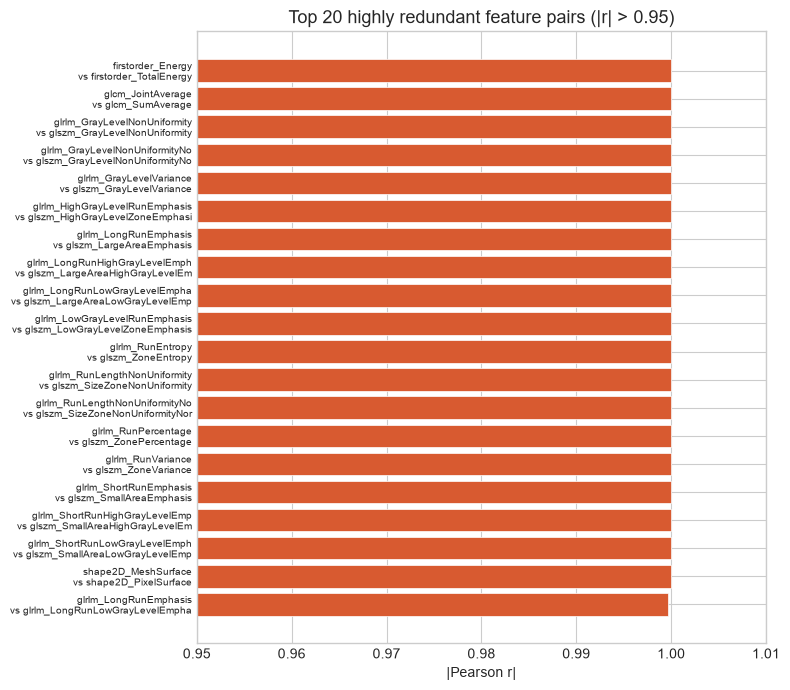

In [42]:
# =========================
# 10. Feature Correlation Analysis (7×7 Family-Level + Top Redundant Pairs)
# =========================

families = {
    "shape2D": [c for c in feature_cols if c.startswith("original_shape2D")],
    "firstorder": [c for c in feature_cols if c.startswith("original_firstorder")],
    "glcm": [c for c in feature_cols if c.startswith("original_glcm")],
    "glrlm": [c for c in feature_cols if c.startswith("original_glrlm")],
    "glszm": [c for c in feature_cols if c.startswith("original_glszm")],
    "gldm": [c for c in feature_cols if c.startswith("original_gldm")],
    "ngtdm": [c for c in feature_cols if c.startswith("original_ngtdm")],
}

corr = df_features[feature_cols].corr()
family_names = list(families.keys())
family_corr = pd.DataFrame(index=family_names, columns=family_names, dtype=float)

for fa in family_names:
    for fb in family_names:
        cols_a, cols_b = families[fa], families[fb]
        if fa == fb:
            vals = np.abs(corr.loc[cols_a, cols_b].values)
            np.fill_diagonal(vals, np.nan)
            family_corr.loc[fa, fb] = np.nanmean(vals)
        else:
            family_corr.loc[fa, fb] = np.abs(corr.loc[cols_a, cols_b]).mean().mean()

# 7×7 heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(family_corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=0, vmax=1, square=True, ax=ax,
            linewidths=1, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Mean |Pearson r|"})
ax.set_title("Feature family-level correlation matrix (7×7)",
             fontsize=14, fontweight=500)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_family_corr_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Print interpretation
print("\n7×7 Family-level correlation interpretation:")
for fa in family_names:
    diag = family_corr.loc[fa, fa]
    level = "high" if diag > 0.5 else "moderate" if diag > 0.3 else "low"
    print(f"  {fa:12s}  intra-family redundancy = {diag:.2f}  ({level})")

# Top |r| > 0.95 redundant pairs
high_pairs = []
for i_idx in range(len(feature_cols)):
    for j_idx in range(i_idx + 1, len(feature_cols)):
        r = corr.iloc[i_idx, j_idx]
        if abs(r) > 0.95:
            high_pairs.append((feature_cols[i_idx].replace("original_", ""),
                               feature_cols[j_idx].replace("original_", ""), r))
high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\n|r| > 0.95 redundant pairs ({len(high_pairs)} total, showing top 15):")
for f1, f2, r in high_pairs[:15]:
    print(f"  {f1:40s} vs {f2:40s}  r = {r:.3f}")

# Top redundant pairs bar chart
if len(high_pairs) > 0:
    top_n = min(20, len(high_pairs))
    labels = [f"{a[:30]}\nvs {b[:30]}" for a, b, _ in high_pairs[:top_n]]
    values = [abs(r) for _, _, r in high_pairs[:top_n]]

    fig, ax = plt.subplots(figsize=(8, max(6, top_n * 0.35)))
    ax.barh(range(top_n), values, color="#D85A30",
            edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(labels, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("|Pearson r|")
    ax.set_title(f"Top {top_n} highly redundant feature pairs (|r| > 0.95)",
                fontsize=13, fontweight=500)
    ax.set_xlim(0.95, 1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "04b_redundant_pairs.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


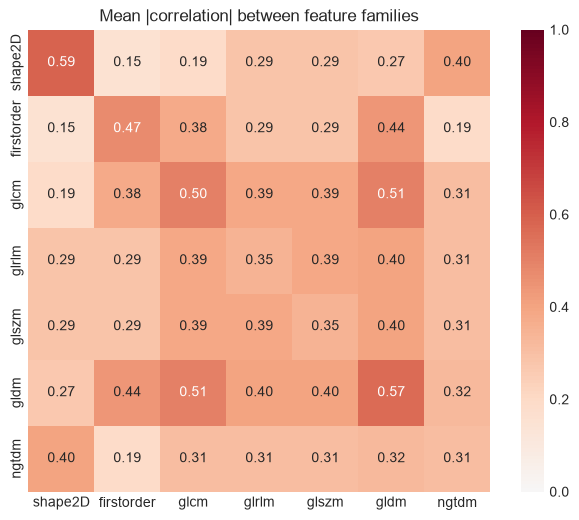

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns

families = {
    "shape2D": [c for c in feature_cols if c.startswith("original_shape2D")],
    "firstorder": [c for c in feature_cols if c.startswith("original_firstorder")],
    "glcm": [c for c in feature_cols if c.startswith("original_glcm")],
    "glrlm": [c for c in feature_cols if c.startswith("original_glrlm")],
    "glszm": [c for c in feature_cols if c.startswith("original_glszm")],
    "gldm": [c for c in feature_cols if c.startswith("original_gldm")],
    "ngtdm": [c for c in feature_cols if c.startswith("original_ngtdm")],
}

corr = df_features[feature_cols].corr()
family_names = list(families.keys())
family_corr = pd.DataFrame(index=family_names, columns=family_names)

for fa in family_names:
    for fb in family_names:
        cols_a, cols_b = families[fa], families[fb]
        # 族间取绝对相关均值；族内排除对角线
        if fa == fb:
            vals = np.abs(corr.loc[cols_a, cols_b].values)
            np.fill_diagonal(vals, np.nan)
            family_corr.loc[fa, fb] = np.nanmean(vals)
        else:
            family_corr.loc[fa, fb] = np.abs(corr.loc[cols_a, cols_b]).mean().mean()

family_corr = family_corr.astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(family_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=0, vmax=1, square=True)
plt.title("Mean |correlation| between feature families")
plt.show()


In [44]:
# =========================
# 11. Preprocessing & Feature Selection
# =========================

X = df_features[feature_cols].values
y = df_features["label"].values
print(f"Feature matrix: {X.shape}, Labels: benign={np.sum(y==0)}, malignant={np.sum(y==1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} (benign={np.sum(y_train==0)}, malignant={np.sum(y_train==1)})")
print(f"Test:  {X_test.shape[0]}  (benign={np.sum(y_test==0)}, malignant={np.sum(y_test==1)})")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

selector = SelectKBest(score_func=f_classif, k=K_BEST)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

selected_mask = selector.get_support()
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]
print(f"\nSelected {len(selected_features)} features (top {K_BEST} by ANOVA F-test):")
for i, feat in enumerate(selected_features, 1):
    score = selector.scores_[np.where(selected_mask)[0][i-1]]
    # Determine category
    cat = "other"
    for prefix, name in [("original_shape2D","shape2D"), ("original_firstorder","firstorder"),
                          ("original_glcm","glcm"), ("original_glrlm","glrlm"),
                          ("original_glszm","glszm"), ("original_gldm","gldm"), ("original_ngtdm","ngtdm")]:
        if feat.startswith(prefix):
            cat = name
            break
    print(f"  {i:2d}. [{cat:10s}] {feat:50s}  F-score = {score:.2f}")

Feature matrix: (647, 102), Labels: benign=437, malignant=210
Train: 517 (benign=349, malignant=168)
Test:  130  (benign=88, malignant=42)

Selected 20 features (top 20 by ANOVA F-test):
   1. [shape2D   ] original_shape2D_MajorAxisLength                    F-score = 61.36
   2. [shape2D   ] original_shape2D_MaximumDiameter                    F-score = 87.36
   3. [shape2D   ] original_shape2D_MeshSurface                        F-score = 75.27
   4. [shape2D   ] original_shape2D_MinorAxisLength                    F-score = 159.07
   5. [shape2D   ] original_shape2D_Perimeter                          F-score = 181.21
   6. [shape2D   ] original_shape2D_PerimeterSurfaceRatio              F-score = 64.69
   7. [shape2D   ] original_shape2D_PixelSurface                       F-score = 75.27
   8. [shape2D   ] original_shape2D_Sphericity                         F-score = 191.79
   9. [glrlm     ] original_glrlm_GrayLevelNonUniformity               F-score = 67.45
  10. [glrlm     ] original

findfont: Failed to find font weight 500, now using 400.


SelectKBest selected features per family:
  shape2D     : 8/9 selected (89%)
  glrlm       : 4/16 selected (25%)
  glszm       : 4/16 selected (25%)
  ngtdm       : 3/5 selected (60%)
  gldm        : 1/14 selected (7%)


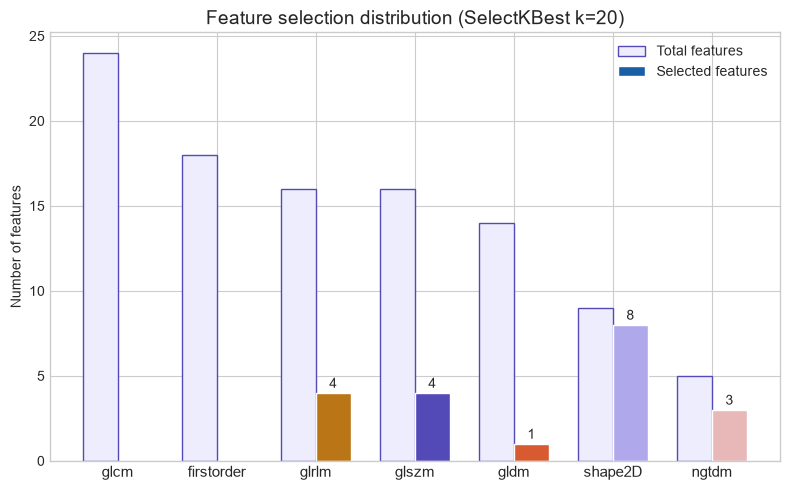

In [45]:
# =========================
# 11b. Selected Feature Family Distribution
# =========================

from collections import Counter

family_counter = Counter()
family_total = {name: len(cols) for name, cols in feature_categories.items()}

for feat in selected_features:
    for prefix, name in [("original_shape2D","shape2D"), ("original_firstorder","firstorder"),
                          ("original_glcm","glcm"), ("original_glrlm","glrlm"),
                          ("original_glszm","glszm"), ("original_gldm","gldm"), ("original_ngtdm","ngtdm")]:
        if feat.startswith(prefix):
            family_counter[name] += 1
            break

print("SelectKBest selected features per family:")
for name in sorted(family_counter, key=lambda x: -family_counter[x]):
    count = family_counter[name]
    total = family_total[name]
    print(f"  {name:12s}: {count}/{total} selected ({count/total*100:.0f}%)")

# Bar chart: total vs selected per family
fig, ax = plt.subplots(figsize=(8, 5))
family_order = sorted(family_total.keys(), key=lambda x: -family_total[x])
selected_counts = [family_counter.get(name, 0) for name in family_order]
total_counts = [family_total[name] for name in family_order]

sel_colors = ["#185FA5", "#0F6E56", "#BA7517", "#534AB7", "#D85A30", "#AFA9EC", "#E8B8B8"]
x = np.arange(len(family_order))
width = 0.35

bars_total = ax.bar(x - width/2, total_counts, width, label="Total features",
                    color="#EEEDFE", edgecolor="#534AB7", linewidth=1)
bars_sel = ax.bar(x + width/2, selected_counts, width, label="Selected features",
                   color=sel_colors[:len(family_order)], edgecolor="white", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(family_order, fontsize=11)
ax.set_ylabel("Number of features")
ax.set_title(f"Feature selection distribution (SelectKBest k={K_BEST})",
            fontsize=14, fontweight=500)
ax.legend(fontsize=10)

for bar, count in zip(bars_sel, selected_counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(count), ha="center", fontsize=10, fontweight=500)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_feature_selection_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## Model Training

All models use `class_weight='balanced'` to handle class imbalance (benign:malignant ~ 2:1):
- Logistic Regression — linear, interpretable coefficients
- Random Forest — nonlinear ensemble, Gini importance
- SVM (RBF kernel) — kernel trick maps to high-dimensional space

In [46]:
# =========================
# 12. Model Training
# =========================

lr_model = LogisticRegression(
    class_weight="balanced", C=1.0, max_iter=1000, random_state=RANDOM_STATE
)
rf_model = RandomForestClassifier(
    class_weight="balanced", n_estimators=200, max_depth=10, random_state=RANDOM_STATE
)
svm_model = SVC(
    class_weight="balanced", kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE
)

models = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    "SVM (RBF)":           svm_model,
}

for name, model in models.items():
    model.fit(X_train_sel, y_train)
    print(f"{name} trained")

Logistic Regression trained
Random Forest trained
SVM (RBF) trained


## 5-Fold Cross-Validation

StratifiedKFold ensures consistent class ratio per fold.

5-fold Cross-validation (AUC):
  Logistic Regression        AUC = 0.9649 +/- 0.0163
    per-fold: ['0.9748', '0.9395', '0.9710', '0.9537', '0.9855']
  Random Forest              AUC = 0.9405 +/- 0.0435
    per-fold: ['0.9895', '0.8641', '0.9749', '0.9370', '0.9369']
  SVM (RBF)                  AUC = 0.9633 +/- 0.0188
    per-fold: ['0.9895', '0.9345', '0.9771', '0.9580', '0.9574']


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

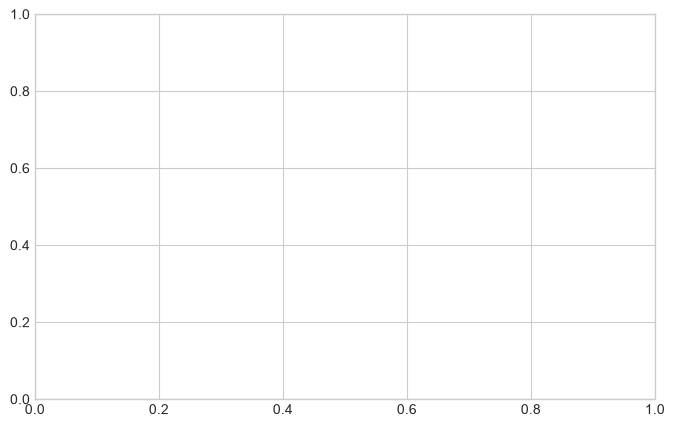

In [47]:
# =========================
# 13. 5-Fold Cross-Validation
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print("5-fold Cross-validation (AUC):")
for name, model in models.items():
    scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"  {name:25s}  AUC = {scores.mean():.4f} +/- {scores.std():.4f}")
    print(f"    per-fold: {[f'{s:.4f}' for s in scores]}")

fig, ax = plt.subplots(figsize=(8, 5))
cv_data = [cv_results[n] for n in models]
bp = ax.boxplot(cv_data, labels=list(models.keys()), patch_artist=True)
for patch, name in zip(bp["boxes"], models):
    patch.set_facecolor(MODEL_COLORS[name])
    patch.set_alpha(0.6)
ax.set_title("5-fold CV AUC comparison", fontsize=14, fontweight=500)
ax.set_ylabel("AUC")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_cv_boxplot.png"), dpi=150, bbox_inches="tight")
plt.show()

## Test Set Evaluation

Four metrics + Bootstrap AUC 95% CI + ROC/PR curves + Confusion matrices

In [ ]:
# =========================
# 14. Performance Metrics + Bootstrap CI
# =========================

def bootstrap_auc(y_true, y_prob, n_boot=N_BOOTSTRAP, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    low, high = np.percentile(aucs, [2.5, 97.5])
    return np.mean(aucs), low, high

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1]

    auc_val = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred)  # sensitivity = recall for positive class
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)  # specificity

    auc_mean, auc_low, auc_high = bootstrap_auc(y_test, y_prob)

    results.append({
        "Model": name, "AUC": auc_val,
        "AUC 95% CI": f"[{auc_low:.3f}, {auc_high:.3f}]",
        "Accuracy": acc, "Sensitivity": sens, "Specificity": spec
    })

df_results = pd.DataFrame(results)
display(df_results.style.format({
    "AUC": "{:.4f}", "Accuracy": "{:.4f}",
    "Sensitivity": "{:.4f}", "Specificity": "{:.4f}"
}))

best = df_results.loc[df_results["AUC"].idxmax()]
print(f"\nBest model (by AUC): {best['Model']}  AUC={best['AUC']:.4f}  CI={best['AUC 95% CI']}")

,Model,AUC,AUC 95% CI,Accuracy,Sensitivity,Specificity
0,Logistic Regression,0.9646,"[0.929, 0.992]",0.9308,0.9524,0.9205
1,Random Forest,0.9159,"[0.854, 0.967]",0.8846,0.8333,0.9091
2,SVM (RBF),0.9410,"[0.891, 0.985]",0.9308,0.9048,0.9432



Best model (by AUC): Logistic Regression  AUC=0.9646  CI=[0.929, 0.992]


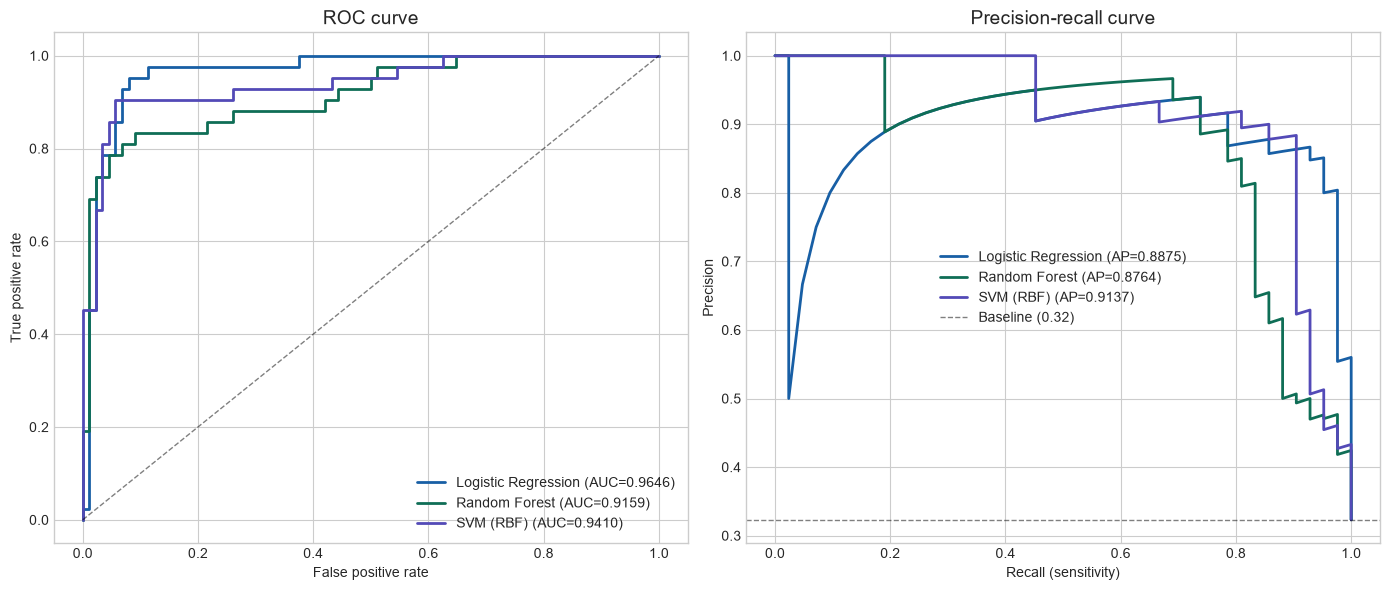

In [ ]:
# =========================
# 15. ROC & PR Curves
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2,
                 label=f"{name} (AUC={auc_val:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[0].set_title("ROC curve", fontsize=14, fontweight=500)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(fontsize=10)

for name, model in models.items():
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall, precision, color=MODEL_COLORS[name], linewidth=2,
                 label=f"{name} (AP={ap:.4f})")

baseline = np.sum(y_test == 1) / len(y_test)
axes[1].axhline(baseline, color="k", linestyle="--", linewidth=1, alpha=0.5,
                label=f"Baseline ({baseline:.2f})")
axes[1].set_title("Precision-recall curve", fontsize=14, fontweight=500)
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_roc_pr_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

findfont: Failed to find font weight 500, now using 400.


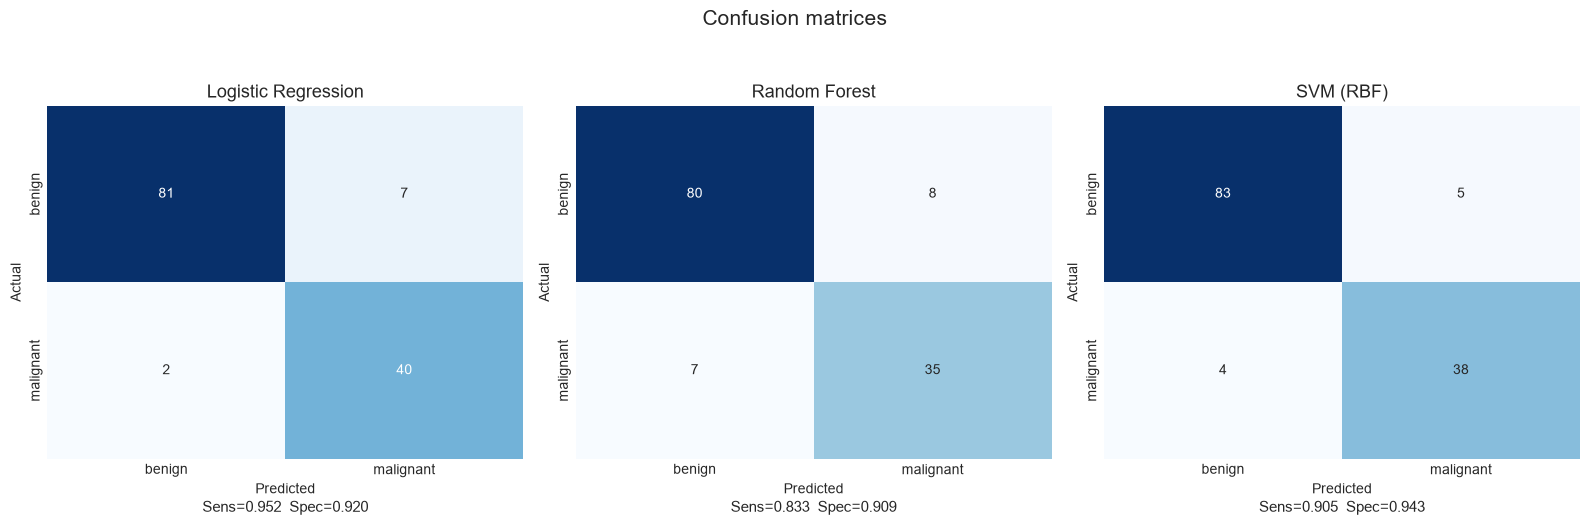

In [ ]:
# =========================
# 16. Confusion Matrices
# =========================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["benign", "malignant"],
                yticklabels=["benign", "malignant"], cbar=False)
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(name, fontsize=13, fontweight=500)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].text(0.5, -0.15,
                 f"Sens={tp/(tp+fn):.3f}  Spec={tn/(tn+fp):.3f}",
                 transform=axes[i].transAxes, ha="center", fontsize=11)

plt.suptitle("Confusion matrices", fontsize=15, fontweight=500, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

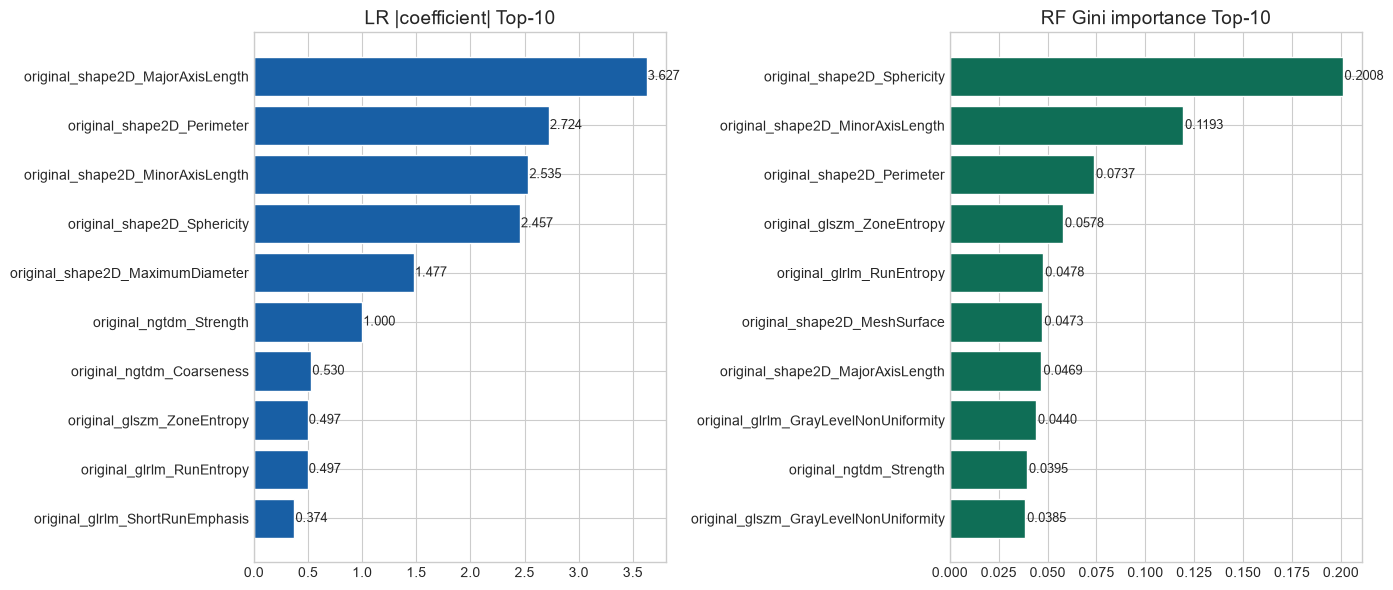


LR ∩ RF common important features (7):
  original_ngtdm_Strength                             LR rank=6, RF rank=9
  original_shape2D_Perimeter                          LR rank=2, RF rank=3
  original_shape2D_Sphericity                         LR rank=4, RF rank=1
  original_shape2D_MinorAxisLength                    LR rank=3, RF rank=2
  original_shape2D_MajorAxisLength                    LR rank=1, RF rank=7
  original_glszm_ZoneEntropy                          LR rank=8, RF rank=4
  original_glrlm_RunEntropy                           LR rank=9, RF rank=5

These features are highly ranked in both models, indicating stable discriminative power.


In [ ]:
# =========================
# 17. Feature Importance (Top-10 + Common Features)
# =========================

lr_importance = np.abs(lr_model.coef_[0])
lr_top_idx = np.argsort(lr_importance)[::-1][:10]
lr_top_feats = [selected_features[i] for i in lr_top_idx]
lr_top_vals = lr_importance[lr_top_idx]

rf_importance = rf_model.feature_importances_
rf_top_idx = np.argsort(rf_importance)[::-1][:10]
rf_top_feats = [selected_features[i] for i in rf_top_idx]
rf_top_vals = rf_importance[rf_top_idx]

common_feats = set(lr_top_feats) & set(rf_top_feats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(10), lr_top_vals, color="#185FA5", edgecolor="white")
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(lr_top_feats)
axes[0].invert_yaxis()
axes[0].set_title("LR |coefficient| Top-10", fontsize=14, fontweight=500)
for j, v in enumerate(lr_top_vals):
    axes[0].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

axes[1].barh(range(10), rf_top_vals, color="#0F6E56", edgecolor="white")
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(rf_top_feats)
axes[1].invert_yaxis()
axes[1].set_title("RF Gini importance Top-10", fontsize=14, fontweight=500)
for j, v in enumerate(rf_top_vals):
    axes[1].text(v + 0.001, j, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLR ∩ RF common important features ({len(common_feats)}):")
for feat in common_feats:
    lr_rank = lr_top_feats.index(feat) + 1
    rf_rank = rf_top_feats.index(feat) + 1
    print(f"  {feat:50s}  LR rank={lr_rank}, RF rank={rf_rank}")
print("\nThese features are highly ranked in both models, indicating stable discriminative power.")

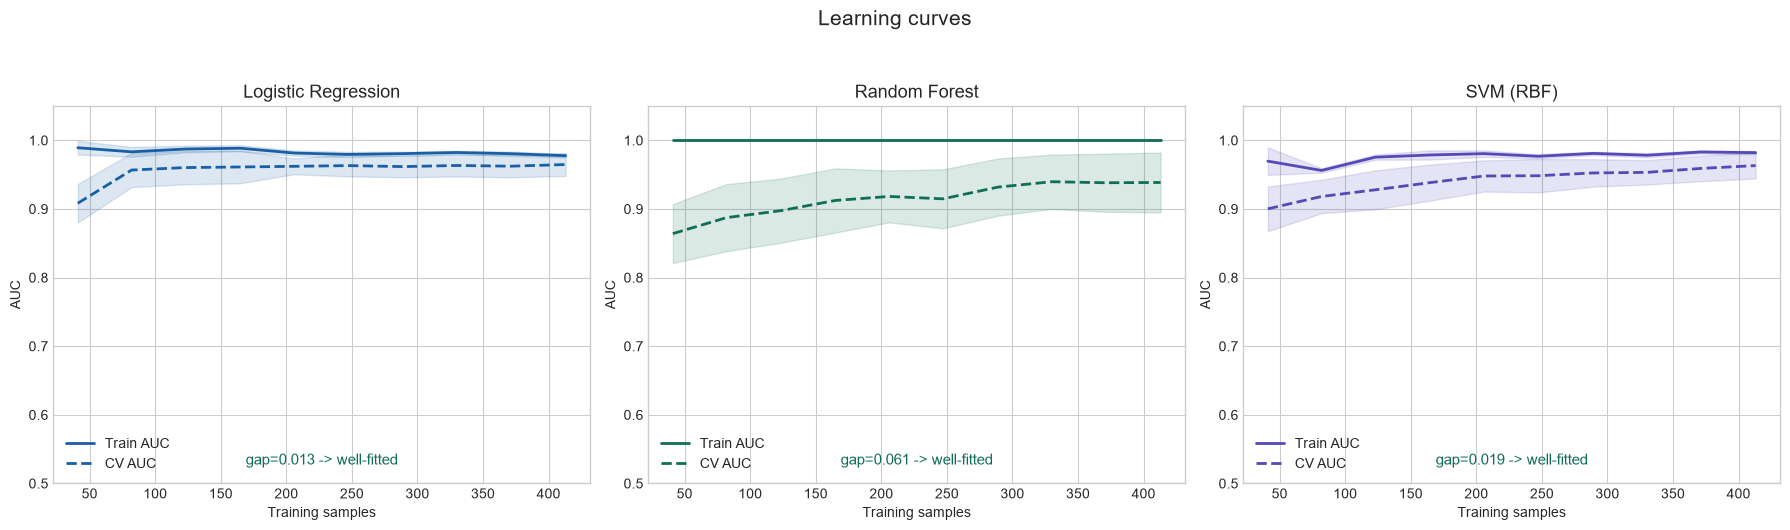

In [ ]:
# =========================
# 18. Learning Curves
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_sel, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc", n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    test_mean  = test_scores.mean(axis=1)
    test_std   = test_scores.std(axis=1)

    axes[i].plot(train_sizes, train_mean, color=MODEL_COLORS[name], linewidth=2,
                 label="Train AUC")
    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                         color=MODEL_COLORS[name], alpha=0.15)
    axes[i].plot(train_sizes, test_mean, color=MODEL_COLORS[name], linewidth=2,
                 linestyle="--", label="CV AUC")
    axes[i].fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                         color=MODEL_COLORS[name], alpha=0.15)
    axes[i].set_title(name, fontsize=13, fontweight=500)
    axes[i].set_xlabel("Training samples")
    axes[i].set_ylabel("AUC")
    axes[i].legend(fontsize=10)
    axes[i].set_ylim(0.5, 1.05)

    gap = train_mean[-1] - test_mean[-1]
    if gap > 0.1:
        diag = "overfitting"
    elif test_mean[-1] < 0.7:
        diag = "underfitting"
    else:
        diag = "well-fitted"
    axes[i].text(0.5, 0.05, f"gap={gap:.3f} -> {diag}",
                 transform=axes[i].transAxes, ha="center", fontsize=11,
                 color="#D85A30" if diag == "overfitting" else "#0F6E56")

plt.suptitle("Learning curves", fontsize=15, fontweight=500, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# 19. SHAP Interpretability
# =========================

if HAS_SHAP:
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_sel)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[1], X_test_sel, feature_names=selected_features,
                      show=False, max_display=15)
    plt.title("SHAP summary plot (Random Forest)", fontsize=14, fontweight=500)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "11_shap_summary.png"), dpi=150, bbox_inches="tight")
    plt.show()

    malignant_idx = np.where(y_test == 1)[0][0]
    plt.figure(figsize=(14, 3))
    shap.force_plot(explainer.expected_value[1], shap_values[1][malignant_idx],
                    X_test_sel[malignant_idx], feature_names=selected_features,
                    matplotlib=True, show=False)
    plt.title(f"SHAP force plot (sample: malignant #{malignant_idx})", fontsize=12, fontweight=500)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "11_shap_force.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SHAP not installed, skipping interpretability analysis")
    print("Install: pip install shap")

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x800 with 0 Axes>

In [ ]:
# =========================
# 20. GridSearchCV
# =========================

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc", n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sel, y_train)

print("Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV AUC: {grid_search.best_score_:.4f}")

rf_default_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test_sel)[:, 1])
rf_opt_auc = roc_auc_score(y_test, grid_search.best_estimator_.predict_proba(X_test_sel)[:, 1])
print(f"\nRandom Forest optimization comparison:")
print(f"  Default AUC: {rf_default_auc:.4f}")
print(f"  Optimized AUC: {rf_opt_auc:.4f}")
print(f"  Improvement: {rf_opt_auc - rf_default_auc:+.4f}")

Best parameters:
  max_depth: 10
  min_samples_split: 2
  n_estimators: 200

Best CV AUC: 0.9405

Random Forest optimization comparison:
  Default AUC: 0.9159
  Optimized AUC: 0.9159
  Improvement: +0.0000
